<a href="https://colab.research.google.com/github/ROKIB-UMMC24/Assignment/blob/master/auto_mpg_1_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [114]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [115]:
!ls "/content/drive/MyDrive"


'1 (Joined by Happy Scribe).mp3'
 5488XXXXXXXX8499-Sep-2024.pdf
 Admission
 Application.docx
 appointmentconfirmation.pdf
'Assignment 4 Md Mushfiqur Rahman.docx'
'Call in Southern Water.mp4'
'Colab Notebooks'
'Copy of Invitation List- 05-January-night2.gsheet'
'Copy of Invitation List- 05-January-night2.xlsx'
'Copy of Lab01_auto-mpg.csv'
 Documents
'DO letter for Universities.docx'
'Editable_LPC Form2.gdoc'
'Editable_LPC Form2.pdf'
'Emails Working Group.docx'
'Emails Working Group.gdoc'
 Faridpur.pdf
 favicon.ico
'Getting started.pdf'
'HBES survey questionnaire 30 may (7.40 pm).pdf'
'Job Related'
 lab-twogrps-stata_Priddy.docx
'nothi_324_2022_02_06_41644121696 (2).xlsx'
 NSPD
'Ohid salary statement.gdoc'
'Rokib Sir.zip'
 statistical-act.pdf
 Untitled
 Untitled0.ipynb


In [116]:
!ls "/content/drive/MyDrive/Colab Notebooks"


Lab01_auto-mpg.csv  Untitled0.ipynb


In [117]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Lab01_auto-mpg.csv")


1. mpg: continuous. (mpg is miles per gallon)
2. cylinders: multi-valued discrete
3. displacement: continuous
4. horsepower: continuous
5. weight: continuous
6. acceleration: continuous
7. model year: multi-valued discrete
8. origin: multi-valued discrete
9. car name: string (unique for each instance)

In [118]:
df.shape

(398, 9)

In [119]:
df.columns

Index(['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'model year', 'origin', 'car name'],
      dtype='object')

In [120]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    object 
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    object 
dtypes: float64(3), int64(4), object(2)
memory usage: 28.1+ KB


In [121]:
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


In [122]:
df.isna().sum()

,0
mpg,0
cylinders,0
displacement,0
horsepower,0
weight,0
acceleration,0
model year,0
origin,0
car name,0


In [123]:
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(df, test_size=0.2, random_state=42)

In [124]:
auto = train_set.copy()

In [125]:
auto.shape

(318, 9)

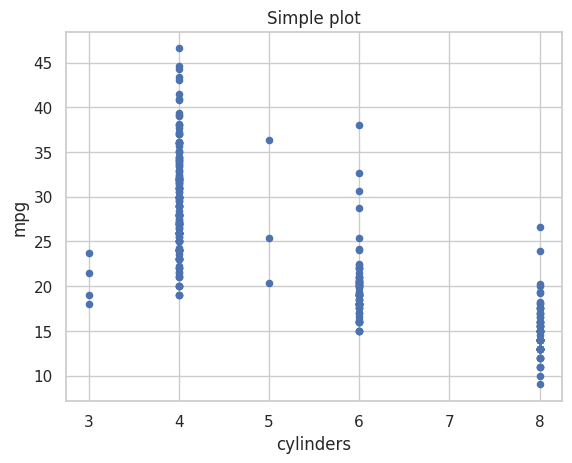

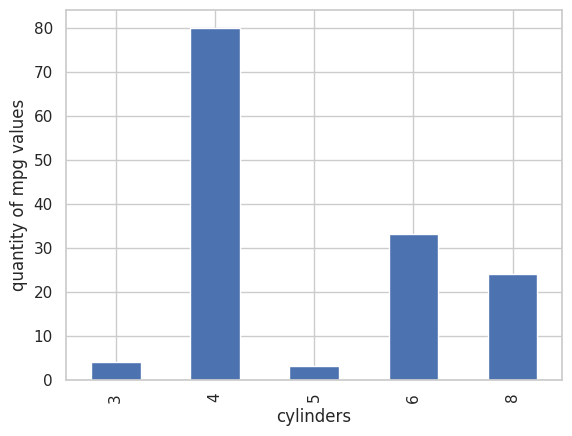

In [126]:
auto.plot(kind='scatter', x='cylinders', y='mpg', xlabel='cylinders', ylabel='mpg',
       title='Simple plot')
plt.show()

auto.groupby('cylinders')['mpg'].nunique().plot(kind='bar', xlabel='cylinders', ylabel='quantity of mpg values')
plt.show()

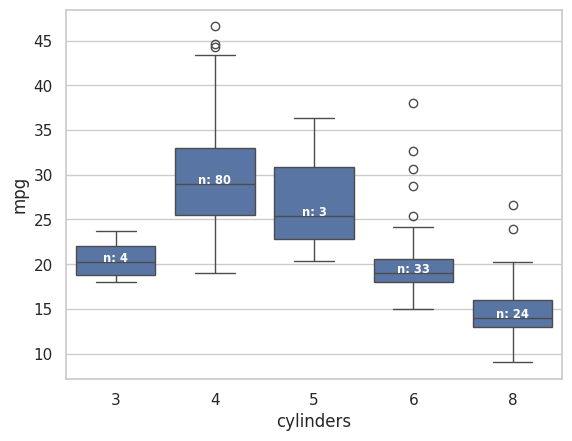

In [127]:
sns.set_theme(style="whitegrid")
ax = sns.boxplot(x="cylinders", y="mpg", data=auto)

# Calculate number of obs per group & median to position labels
medians = auto.groupby('cylinders')['mpg'].median().values
nobs = auto.groupby('cylinders')['mpg'].nunique().values
nobs = [str(x) for x in nobs.tolist()]
nobs = ["n: " + i for i in nobs]

# Add it to the plot
pos = range(len(nobs))
for tick,label in zip(pos,ax.get_xticklabels()):
  ax.text(pos[tick], medians[tick] + 0.03, nobs[tick],
  horizontalalignment='center', size='x-small', color='w', weight='semibold')

In [128]:
auto.groupby(['cylinders'])['mpg'].nunique().values

array([ 4, 80,  3, 33, 24])

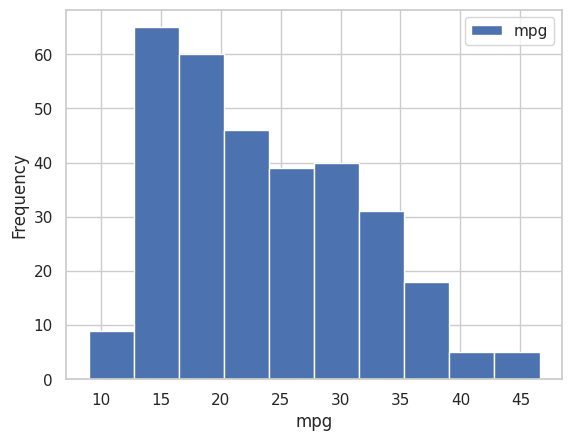

In [129]:
auto.plot(kind='hist', y='mpg', xlabel='mpg')
plt.show()

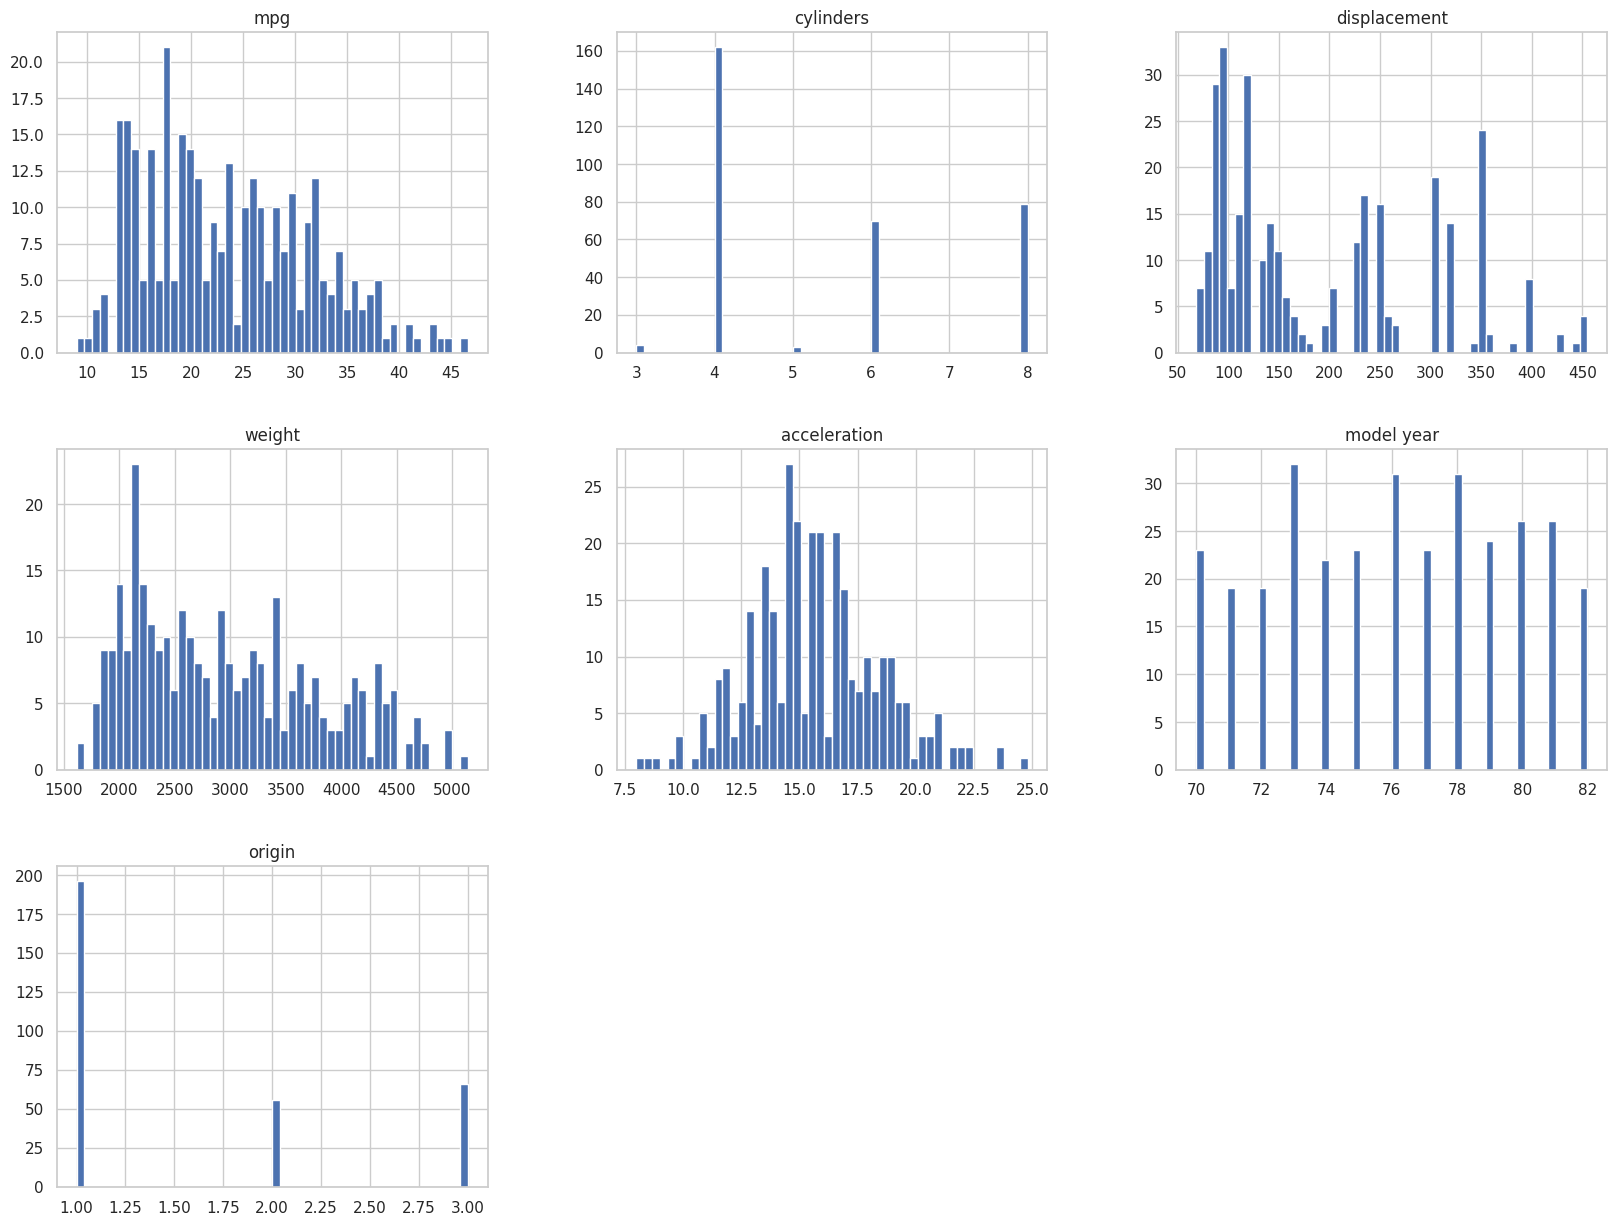

In [130]:
auto.hist(bins=50, figsize=(20,15))
plt.show()

array([[<Axes: xlabel='mpg', ylabel='mpg'>,
        <Axes: xlabel='cylinders', ylabel='mpg'>,
        <Axes: xlabel='displacement', ylabel='mpg'>,
        <Axes: xlabel='weight', ylabel='mpg'>,
        <Axes: xlabel='acceleration', ylabel='mpg'>,
        <Axes: xlabel='model year', ylabel='mpg'>,
        <Axes: xlabel='origin', ylabel='mpg'>],
       [<Axes: xlabel='mpg', ylabel='cylinders'>,
        <Axes: xlabel='cylinders', ylabel='cylinders'>,
        <Axes: xlabel='displacement', ylabel='cylinders'>,
        <Axes: xlabel='weight', ylabel='cylinders'>,
        <Axes: xlabel='acceleration', ylabel='cylinders'>,
        <Axes: xlabel='model year', ylabel='cylinders'>,
        <Axes: xlabel='origin', ylabel='cylinders'>],
       [<Axes: xlabel='mpg', ylabel='displacement'>,
        <Axes: xlabel='cylinders', ylabel='displacement'>,
        <Axes: xlabel='displacement', ylabel='displacement'>,
        <Axes: xlabel='weight', ylabel='displacement'>,
        <Axes: xlabel='acceleration'

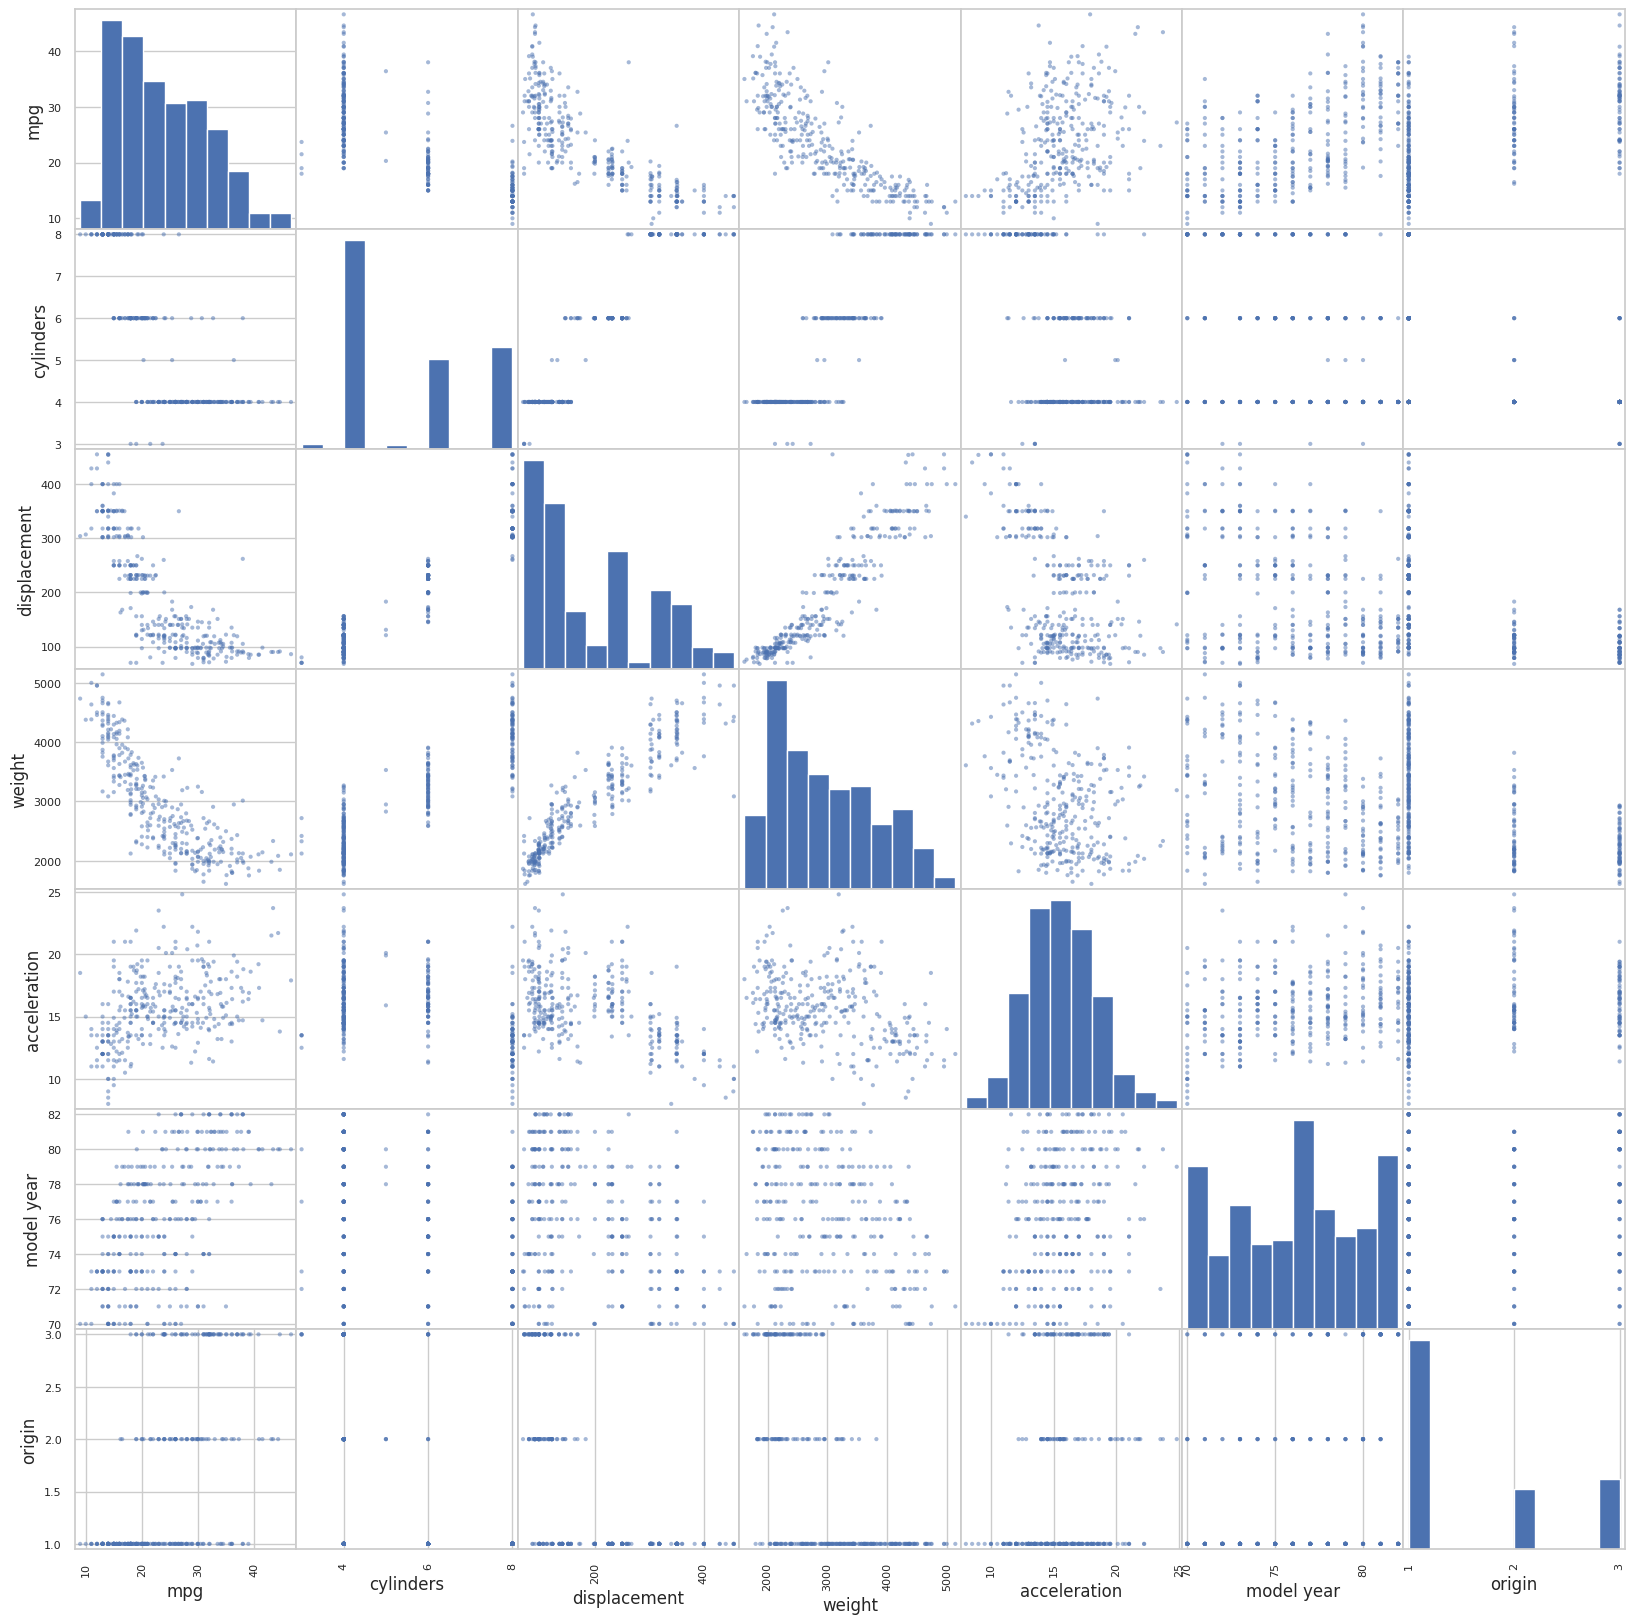

In [131]:
from pandas.plotting import scatter_matrix

attributes = ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
              'acceleration', 'model year', 'origin', 'car name']
scatter_matrix(auto[attributes], figsize=(20, 20))

There are a few correlations:
1. mpg vs. displacement
2. mpg vs. weight
3. mpg vs. acceleration
4. displacement vs. acceleration
5. displacement vs. weight
6. acceleration vs. weight

But most of these are non-linear correlations.

In [132]:
auto.describe(include='all')

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
count,318.000000,318.000000,318.000000,318,318.000000,318.000000,318.000000,318.000000,318
unique,NaN,NaN,NaN,90,NaN,NaN,NaN,NaN,246
top,NaN,NaN,NaN,90,NaN,NaN,NaN,NaN,amc matador
freq,NaN,NaN,NaN,17,NaN,NaN,NaN,NaN,5
mean,23.608176,5.430818,191.904088,NaN,2969.015723,15.639937,76.103774,1.591195,NaN
std,7.930574,1.684947,102.983802,NaN,840.617729,2.763269,3.603177,0.811696,NaN
min,9.000000,3.000000,68.000000,NaN,1613.000000,8.000000,70.000000,1.000000,NaN
25%,17.500000,4.000000,98.500000,NaN,2220.000000,13.900000,73.000000,1.000000,NaN
50%,22.450000,4.000000,148.500000,NaN,2822.500000,15.500000,76.000000,1.000000,NaN
75%,29.725000,6.000000,259.500000,NaN,3597.250000,17.300000,79.000000,2.000000,NaN


In [133]:
auto['mpg'].describe()

,mpg
count,318.000000
mean,23.608176
std,7.930574
min,9.000000
25%,17.500000
50%,22.450000
75%,29.725000
max,46.600000


In [134]:
auto['car name'].value_counts().head(20)

,count
car name,
amc matador,5
toyota corolla,5
ford pinto,5
chevrolet chevette,4
ford maverick,4
amc hornet,4
chevrolet impala,4
peugeot 504,4
amc gremlin,3


In [135]:
auto.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
18,27.0,4,97.0,88,2130,14.5,70,3,datsun pl510
376,37.0,4,91.0,68,2025,18.2,82,3,mazda glc custom l
248,36.1,4,91.0,60,1800,16.4,78,3,honda civic cvcc
177,23.0,4,115.0,95,2694,15.0,75,2,audi 100ls


In [136]:
auto_wo_name = df.drop('car name', axis=1)


In [137]:
auto_wo_name


,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin
0,18.0,8,307.0,130,3504,12.0,70,1
1,15.0,8,350.0,165,3693,11.5,70,1
2,18.0,8,318.0,150,3436,11.0,70,1
3,16.0,8,304.0,150,3433,12.0,70,1
4,17.0,8,302.0,140,3449,10.5,70,1
...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86,2790,15.6,82,1
394,44.0,4,97.0,52,2130,24.6,82,2
395,32.0,4,135.0,84,2295,11.6,82,1
396,28.0,4,120.0,79,2625,18.6,82,1


In [138]:
auto_wo_name['horsepower']

,horsepower
0,130
1,165
2,150
3,150
4,140
...,...
393,86
394,52
395,84
396,79


In [139]:

auto_wo_name['horsepower'].dtype


dtype('O')

In [140]:
auto['horsepower'].unique()


array(['150', '88', '68', '60', '95', '175', '52', '65', '198', '190',
       '100', '75', '58', '108', '63', '84', '115', '105', '66', '94',
       '97', '215', '46', '74', '86', '125', '67', '80', '90', '69',
       '110', '133', '145', '72', '85', '116', '70', '61', '91', '140',
       '142', '54', '96', '220', '138', '103', '93', '170', '92', '71',
       '120', '158', '160', '122', '78', '98', '155', '113', '208', '81',
       '?', '165', '48', '79', '132', '49', '129', '76', '149', '200',
       '112', '130', '153', '83', '148', '193', '225', '77', '62', '210',
       '135', '89', '102', '180', '139', '152', '137', '64', '82', '87'],
      dtype=object)

In [141]:
auto_wo_name.isna().sum()
auto_wo_name.isnull().sum()

,0
mpg,0
cylinders,0
displacement,0
horsepower,0
weight,0
acceleration,0
model year,0
origin,0


In [142]:
#auto_wo_name['horsepower'] = pd.to_numeric(auto_wo_name['horsepower'], errors='coerce')
auto_wo_name['horsepower'] = auto_wo_name['horsepower'].replace('?', np.nan)
auto_wo_name['horsepower'].unique()


array(['130', '165', '150', '140', '198', '220', '215', '225', '190',
       '170', '160', '95', '97', '85', '88', '46', '87', '90', '113',
       '200', '210', '193', nan, '100', '105', '175', '153', '180', '110',
       '72', '86', '70', '76', '65', '69', '60', '80', '54', '208', '155',
       '112', '92', '145', '137', '158', '167', '94', '107', '230', '49',
       '75', '91', '122', '67', '83', '78', '52', '61', '93', '148',
       '129', '96', '71', '98', '115', '53', '81', '79', '120', '152',
       '102', '108', '68', '58', '149', '89', '63', '48', '66', '139',
       '103', '125', '133', '138', '135', '142', '77', '62', '132', '84',
       '64', '74', '116', '82'], dtype=object)

In [143]:
# KNN imputation for horsepower

from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
auto_scaled = scaler.fit_transform(auto_wo_name)

imputer = KNNImputer(n_neighbors=5)
auto_scaled_imputed = imputer.fit_transform(auto_scaled)

auto_knn = pd.DataFrame(
    scaler.inverse_transform(auto_scaled_imputed),
    columns=auto_wo_name.columns
)
auto_wo_name[:] = scaler.inverse_transform(auto_scaled_imputed)


In [144]:
corr_matrix = auto_wo_name.corr() #standard correlation coefficient (also called Pearson’s r)
corr_matrix


,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin
mpg,1.000000,-0.775396,-0.804203,-0.776908,-0.831741,0.420289,0.579267,0.563450
cylinders,-0.775396,1.000000,0.950721,0.843199,0.896017,-0.505419,-0.348746,-0.562543
displacement,-0.804203,0.950721,1.000000,0.897681,0.932824,-0.543684,-0.370164,-0.609409
horsepower,-0.776908,0.843199,0.897681,1.000000,0.864617,-0.688145,-0.415398,-0.451450
weight,-0.831741,0.896017,0.932824,0.864617,1.000000,-0.417457,-0.306564,-0.581024
acceleration,0.420289,-0.505419,-0.543684,-0.688145,-0.417457,1.000000,0.288137,0.205873
model year,0.579267,-0.348746,-0.370164,-0.415398,-0.306564,0.288137,1.000000,0.180662
origin,0.563450,-0.562543,-0.609409,-0.451450,-0.581024,0.205873,0.180662,1.000000


In [145]:
corr_matrix["mpg"].sort_values(ascending=False)

,mpg
mpg,1.000000
model year,0.579267
origin,0.563450
acceleration,0.420289
cylinders,-0.775396
horsepower,-0.776908
displacement,-0.804203
weight,-0.831741


Most relationships seem to be non-linear, or polynomial.

Let's take the relationship miles per gallon (mpg) vs. displacement, for instance:

- X: the 1st column which contains mpg array

- y: the 3rd column which contains displacement array


## Multiple Linear Regression

Multiple linear regression is represented by the following equation:

$ y = \beta_1 x_1 + \beta_2 x_2 + \cdots + \beta_n x_n + \beta_0\tag{1}$

where $y$ is response variable, $n$ is number of features, $x_n$ is th n-th feature, $\beta_n$ is the regression coefficient (weight) of the n-th feature, and $\beta_0$ is the y-intercept.

Multiple linear regression is an extrapolation on bivariate linear equations, that also constitute their own 2-dimensional models:

$ y = \beta_1 x_1 + \beta_0 \tag{2} $

In the auto-mpg dataset, most continuous variables have relations between each other that seem to be non-linear, or polynomial.

Let's take the relationship miles per gallon (mpg) vs. displacement, for instance:

- X: the 1st column which contains `mpg` array

- y: the 3rd column which contains `displacement` array







In [146]:
# Data needs to be ordered with respect to the predictor
auto = auto.sort_values(by=['mpg'])

X = auto[['mpg']].values
y = auto[['displacement']].values

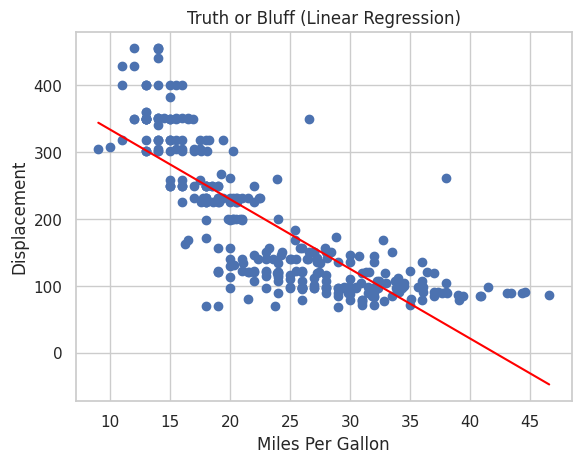

RMSE of linear regression is 61.48093774639589
R2 score of linear regression is 0.6424712414861957


In [147]:
# Fitting Linear Regression to the dataset
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

lin_reg = LinearRegression()
lin_reg.fit(X, y)

# Visualizing the Linear Regression results
def viz_linear():
  plt.scatter(X, y)
  plt.plot(X, lin_reg.predict(X), color='red')
  plt.title('Truth or Bluff (Linear Regression)')
  plt.xlabel('Miles Per Gallon')
  plt.ylabel('Displacement')
  plt.show()
  return
viz_linear()

rmse = np.sqrt(mean_squared_error(y,lin_reg.predict(X)))
r2 = r2_score(y,lin_reg.predict(X))
print('RMSE of linear regression is', rmse)
print('R2 score of linear regression is', r2)

In [157]:
######################## MPG vs Horsepower #######################

# Data needs to be ordered with respect to the predictor
auto = auto_wo_name.sort_values(by=['mpg'])

X = auto[['mpg']].values
y = auto[['horsepower']].values


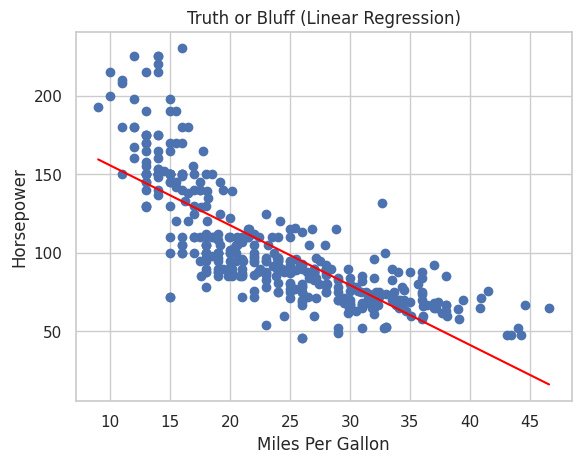

RMSE of linear regression is 24.086140370008387
R2 score of linear regression is 0.6035856208976402


In [158]:


# Fitting Linear Regression to the dataset
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

lin_reg = LinearRegression()
lin_reg.fit(X, y)

# Visualizing the Linear Regression results
def viz_linear():
  plt.scatter(X, y)
  plt.plot(X, lin_reg.predict(X), color='red')
  plt.title('Truth or Bluff (Linear Regression)')
  plt.xlabel('Miles Per Gallon')
  plt.ylabel('Horsepower')
  plt.show()
  return
viz_linear()

rmse = np.sqrt(mean_squared_error(y,lin_reg.predict(X)))
r2 = r2_score(y,lin_reg.predict(X))
print('RMSE of linear regression is', rmse)
print('R2 score of linear regression is', r2)

In [159]:
######################## Horsepower vs Acceleration #######################

# Data needs to be ordered with respect to the predictor
auto = auto_wo_name.sort_values(by=['horsepower'])


X = auto[['horsepower']].values
y = auto[['acceleration']].values

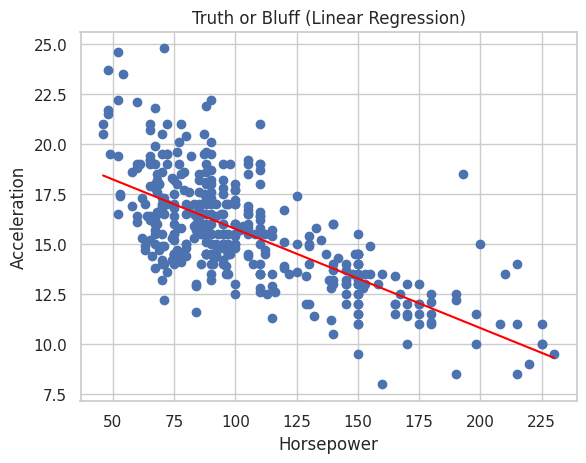

RMSE of linear regression is 1.9983910902741595
R2 score of linear regression is 0.4735429045663444


In [160]:


# Fitting Linear Regression to the dataset
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

lin_reg = LinearRegression()
lin_reg.fit(X, y)

# Visualizing the Linear Regression results
def viz_linear():
  plt.scatter(X, y)
  plt.plot(X, lin_reg.predict(X), color='red')
  plt.title('Truth or Bluff (Linear Regression)')
  plt.xlabel('Horsepower')
  plt.ylabel('Acceleration')
  plt.show()
  return
viz_linear()

rmse = np.sqrt(mean_squared_error(y,lin_reg.predict(X)))
r2 = r2_score(y,lin_reg.predict(X))
print('RMSE of linear regression is', rmse)
print('R2 score of linear regression is', r2)

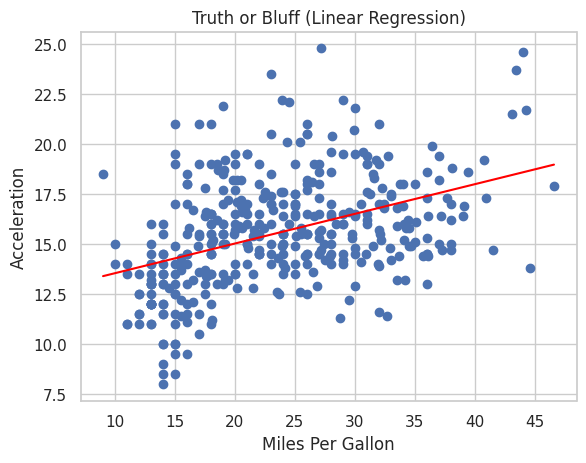

RMSE of linear regression is 2.4991547270777508
R2 score of linear regression is 0.176642769635589


In [161]:
######################## MPG vs Acceleration #######################

# Data needs to be ordered with respect to the predictor
auto = auto_wo_name.sort_values(by=['mpg'])

X = auto[['mpg']].values
y = auto[['acceleration']].values



# Fitting Linear Regression to the dataset
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

lin_reg = LinearRegression()
lin_reg.fit(X, y)

# Visualizing the Linear Regression results
def viz_linear():
  plt.scatter(X, y)
  plt.plot(X, lin_reg.predict(X), color='red')
  plt.title('Truth or Bluff (Linear Regression)')
  plt.xlabel('Miles Per Gallon')
  plt.ylabel('Acceleration')
  plt.show()
  return
viz_linear()

rmse = np.sqrt(mean_squared_error(y,lin_reg.predict(X)))
r2 = r2_score(y,lin_reg.predict(X))
print('RMSE of linear regression is', rmse)
print('R2 score of linear regression is', r2)

In [ ]:
# Fitting Polynomial Regression to the dataset
from sklearn.preprocessing import PolynomialFeatures
poly_reg = PolynomialFeatures(degree=3)
X_poly = poly_reg.fit_transform(X)
pol_reg = LinearRegression()
pol_reg.fit(X_poly, y)

# Visualizing the Polymonial Regression results
def viz_polymonial():
  plt.scatter(X, y)
  plt.plot(X, pol_reg.predict(X_poly), color='red')
  plt.title('Truth or Bluff (Linear Regression)')
  plt.xlabel('Displacement')
  plt.ylabel('Miles Per Gallon')
  plt.show()
  return
viz_polymonial()

rmse = np.sqrt(mean_squared_error(y, pol_reg.predict(X_poly)))
r2 = r2_score(y, pol_reg.predict(X_poly))
print('RMSE of linear regression is', rmse)
print('R2 score of linear regression is', r2)

In [ ]:
# Add a third continuous variable
auto = auto.sort_values(by=['mpg'])
Y = auto[['weight']].values

lin_reg = LinearRegression()
lin_reg.fit(X, Y)

In [ ]:
# Visualizing the Linear Regression results
def viz_linear():
  plt.scatter(X, Y)
  plt.plot(X, lin_reg.predict(X), color='red')
  plt.title('Truth or Bluff (Linear Regression)')
  plt.xlabel('Miles Per Gallon')
  plt.ylabel('Weight')
  plt.show()
  return
viz_linear()

rmse = np.sqrt(mean_squared_error(y,lin_reg.predict(X)))
r2 = r2_score(y,lin_reg.predict(X))
print('RMSE of linear regression is', rmse)
print('R2 score of linear regression is', r2)

In [ ]:
#3-d graph: mpg, displacement and weight
auto = auto.sort_values(by=['mpg', 'displacement'])
X = auto[['mpg', 'displacement']].values.reshape(-1,2)
Y = auto['weight']

x = X[:, 0]
y = X[:, 1]
z = Y

x_pred = np.linspace(np.min(x), np.max(x), 30)   # range of mpg values
y_pred = np.linspace(np.min(y), np.max(y), 30)  # range of displacement values
xx_pred, yy_pred = np.meshgrid(x_pred, y_pred)
model_viz = np.array([xx_pred.flatten(), yy_pred.flatten()]).T

In [ ]:
from sklearn.linear_model import LinearRegression
from mpl_toolkits.mplot3d import Axes3D

ols = LinearRegression()
model = ols.fit(X, Y)
predicted = model.predict(model_viz)
r2 = model.score(X, Y)

plt.style.use('default')

fig = plt.figure(figsize=(12, 4))

ax1 = fig.add_subplot(131, projection='3d')
ax2 = fig.add_subplot(132, projection='3d')
ax3 = fig.add_subplot(133, projection='3d')

axes = [ax1, ax2, ax3]

for ax in axes:
    ax.plot(x, y, z, color='k', zorder=15, linestyle='none', marker='o', alpha=0.5)
    ax.scatter(xx_pred.flatten(), yy_pred.flatten(), predicted, facecolor=(0,0,0,0), s=20, edgecolor='#70b3f0')
    ax.set_xlabel('Miles Per Gallon', fontsize=12)
    ax.set_ylabel('Displacement', fontsize=12)
    ax.set_zlabel('Weight', fontsize=12)
    ax.locator_params(nbins=4, axis='x')
    ax.locator_params(nbins=5, axis='x')

ax1.text2D(0.2, 0.32, 'pedroleite.net', fontsize=13, ha='center', va='center',
           transform=ax1.transAxes, color='grey', alpha=0.5)
ax2.text2D(0.3, 0.72, 'pedroleite.net', fontsize=13, ha='center', va='center',
           transform=ax2.transAxes, color='grey', alpha=0.5)
ax3.text2D(0.85, 0.85, 'pedroleite.net', fontsize=13, ha='center', va='center',
           transform=ax3.transAxes, color='grey', alpha=0.5)

ax1.view_init(elev=4, azim=160)
ax2.view_init(elev=28, azim=100)
ax3.view_init(elev=60, azim=165)

fig.suptitle('$R^2 = %.2f$' % r2, fontsize=20)

fig.tight_layout()

## Learning rates

How to quantitatively determine whether a model is overfitting or underfitting the data?
We could test the learning rates and test them in a diagram. Let's see

In [ ]:
# How does underfitting looks?

from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

def plot_learning_curves(model, X, y):
  X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2)
  train_errors, val_errors = [], []
  for m in range(1, len(X_train)):
    model.fit(X_train[:m], y_train[:m])
    y_train_predict = model.predict(X_train[:m])
    y_val_predict = model.predict(X_val)
    train_errors.append(mean_squared_error(y_train_predict, y_train[:m]))
    val_errors.append(mean_squared_error(y_val_predict, y_val))
  plt.plot(np.sqrt(train_errors), "r-+", linewidth=2, label="train")
  plt.plot(np.sqrt(val_errors), "b-", linewidth=3, label="val")
  legend = ax.legend(loc='upper center', shadow=True, fontsize='x-large')
  legend.get_frame().set_facecolor('C0')

In [ ]:
lin_reg = LinearRegression()
plot_learning_curves(lin_reg, X, Y)

In [ ]:
# How does overfitting looks?
from sklearn.pipeline import Pipeline

polynomial_regression = Pipeline((
    ("poly_features", PolynomialFeatures(degree=10, include_bias=False)),
    ("sgd_reg", LinearRegression()),
  ))
plot_learning_curves(polynomial_regression, X, Y)